In [1]:
import os, sys, math, torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from torchvision import transforms, models
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw

sys.path.append('..')
from dataset import ClockDataset

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Device: {device}")

Device: mps


In [2]:
# ===================== MODEL =====================

class DigitalClockClassifier(nn.Module):
    """
    ResNet18 backbone with 3 independent classification heads:
      - hour_head:   24 classes  (0–23)
      - minute_head: 60 classes  (0–59)
      - second_head: 60 classes  (0–59)

    Why classification instead of regression?
    Regression treats 12:59 and 13:00 as "close" in loss space,
    even though they are very different clock positions.
    Classification treats each digit combination as an independent class,
    so the model can learn crisp decision boundaries.
    """
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat = base.fc.in_features          # 512 for ResNet18
        base.fc = nn.Identity()             # Remove the original head
        self.backbone = base

        # Shared bottleneck (helps all 3 heads)
        self.bottleneck = nn.Sequential(
            nn.Linear(feat, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.hour_head   = nn.Linear(256, 24)
        self.minute_head = nn.Linear(256, 60)
        self.second_head = nn.Linear(256, 60)

    def forward(self, x):
        f = self.backbone(x)
        f = self.bottleneck(f)
        return self.hour_head(f), self.minute_head(f), self.second_head(f)

    def predict_time(self, x):
        """Returns integer (h, m, s) — use this at inference time."""
        h_logits, m_logits, s_logits = self.forward(x)
        h = h_logits.argmax(dim=1)
        m = m_logits.argmax(dim=1)
        s = s_logits.argmax(dim=1)
        return h, m, s

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)
    
class ClockEraserV2(nn.Module):
    """
    4-level U-Net with skip connections.
    Input:  analog image with hands  (B, 3, H, W)
    Output: clean clock face         (B, 3, H, W)  values in [0, 1]
    """
    def __init__(self, base=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(3, base)
        self.enc2 = ConvBlock(base, base*2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.enc4 = ConvBlock(base*4, base*8)
        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck = ConvBlock(base*8, base*8)

        # Decoder
        self.up4  = nn.ConvTranspose2d(base*8, base*8, 2, stride=2)
        self.dec4 = ConvBlock(base*8 + base*8, base*4)

        self.up3  = nn.ConvTranspose2d(base*4, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*4 + base*4, base*2)

        self.up2  = nn.ConvTranspose2d(base*2, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*2 + base*2, base)

        self.up1  = nn.ConvTranspose2d(base, base, 2, stride=2)
        self.dec1 = ConvBlock(base + base, base)

        self.final = nn.Sequential(
            nn.Conv2d(base, 3, 1),
            nn.Sigmoid()   # Output in [0, 1]
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self._up(self.up4, bn, e4), e4], dim=1))
        d3 = self.dec3(torch.cat([self._up(self.up3, d4, e3), e3], dim=1))
        d2 = self.dec2(torch.cat([self._up(self.up2, d3, e2), e2], dim=1))
        d1 = self.dec1(torch.cat([self._up(self.up1, d2, e1), e1], dim=1))

        return self.final(d1)

    @staticmethod
    def _up(upsample, x, skip):
        """Upsample and fix size mismatch from odd dimensions."""
        x = upsample(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return x

In [4]:
def draw_hands_on_tensor(clean_batch, h_batch, m_batch, s_batch):
    """
    Draws pixel-perfect clock hands onto clean clock faces.
    clean_batch : (B, 3, H, W) tensor in [0,1]
    h/m/s_batch : (B,) integer tensors
    Returns     : (B, 3, H, W) tensor in [0,1]
    """
    B, C, H, W = clean_batch.shape
    outputs = []

    for i in range(B):
        face = clean_batch[i].clone()
        h = int(h_batch[i].item())
        m = int(m_batch[i].item())
        s = int(s_batch[i].item())

        # Convert tensor → PIL, draw, convert back
        np_img = (face.permute(1,2,0).cpu().numpy() * 255).astype('uint8')
        pil    = Image.fromarray(np_img)
        draw   = ImageDraw.Draw(pil)

        cx, cy = W / 2, H / 2
        radius = min(W, H) / 2 - max(5, W // 25)

        # Angles: -90 offset so 0 = 12 o'clock, clockwise
        h_angle = math.radians((h % 12) * 30 + m * 0.5 - 90)
        m_angle = math.radians(m * 6   + s * 0.1       - 90)
        s_angle = math.radians(s * 6                   - 90)

        def tip(angle, length):
            return (cx + length * math.cos(angle),
                    cy + length * math.sin(angle))

        # Hour hand — short and thick
        hx, hy = tip(h_angle, radius * 0.50)
        draw.line([cx, cy, hx, hy], fill=(30, 30, 30),
                  width=max(3, int(W * 0.04)))

        # Minute hand — long and medium
        mx, my = tip(m_angle, radius * 0.75)
        draw.line([cx, cy, mx, my], fill=(30, 30, 30),
                  width=max(2, int(W * 0.025)))

        # Second hand — thin and red
        sx2, sy2 = tip(s_angle, radius * 0.85)
        draw.line([cx, cy, sx2, sy2], fill=(200, 40, 40),
                  width=max(1, int(W * 0.008)))

        # Center cap
        r = max(3, W // 40)
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=(30, 30, 30))

        # Back to tensor
        out_t = torch.from_numpy(
            np.array(pil).astype('float32') / 255.0
        ).permute(2, 0, 1)
        outputs.append(out_t)

    return torch.stack(outputs)

In [5]:
# Adjust paths to wherever your checkpoints are saved
READER_CKPT = 'checkpoints/digital_reader_best.pth'
ERASER_CKPT = 'checkpoints/eraser_v2_best.pth'

reader = DigitalClockClassifier().to(device)
reader.load_state_dict(torch.load(READER_CKPT, map_location=device))
reader.eval()
print("Reader loaded ✓")

eraser = ClockEraserV2().to(device)
eraser.load_state_dict(torch.load(ERASER_CKPT, map_location=device))
eraser.eval()
print("Eraser loaded ✓")

Reader loaded ✓
Eraser loaded ✓


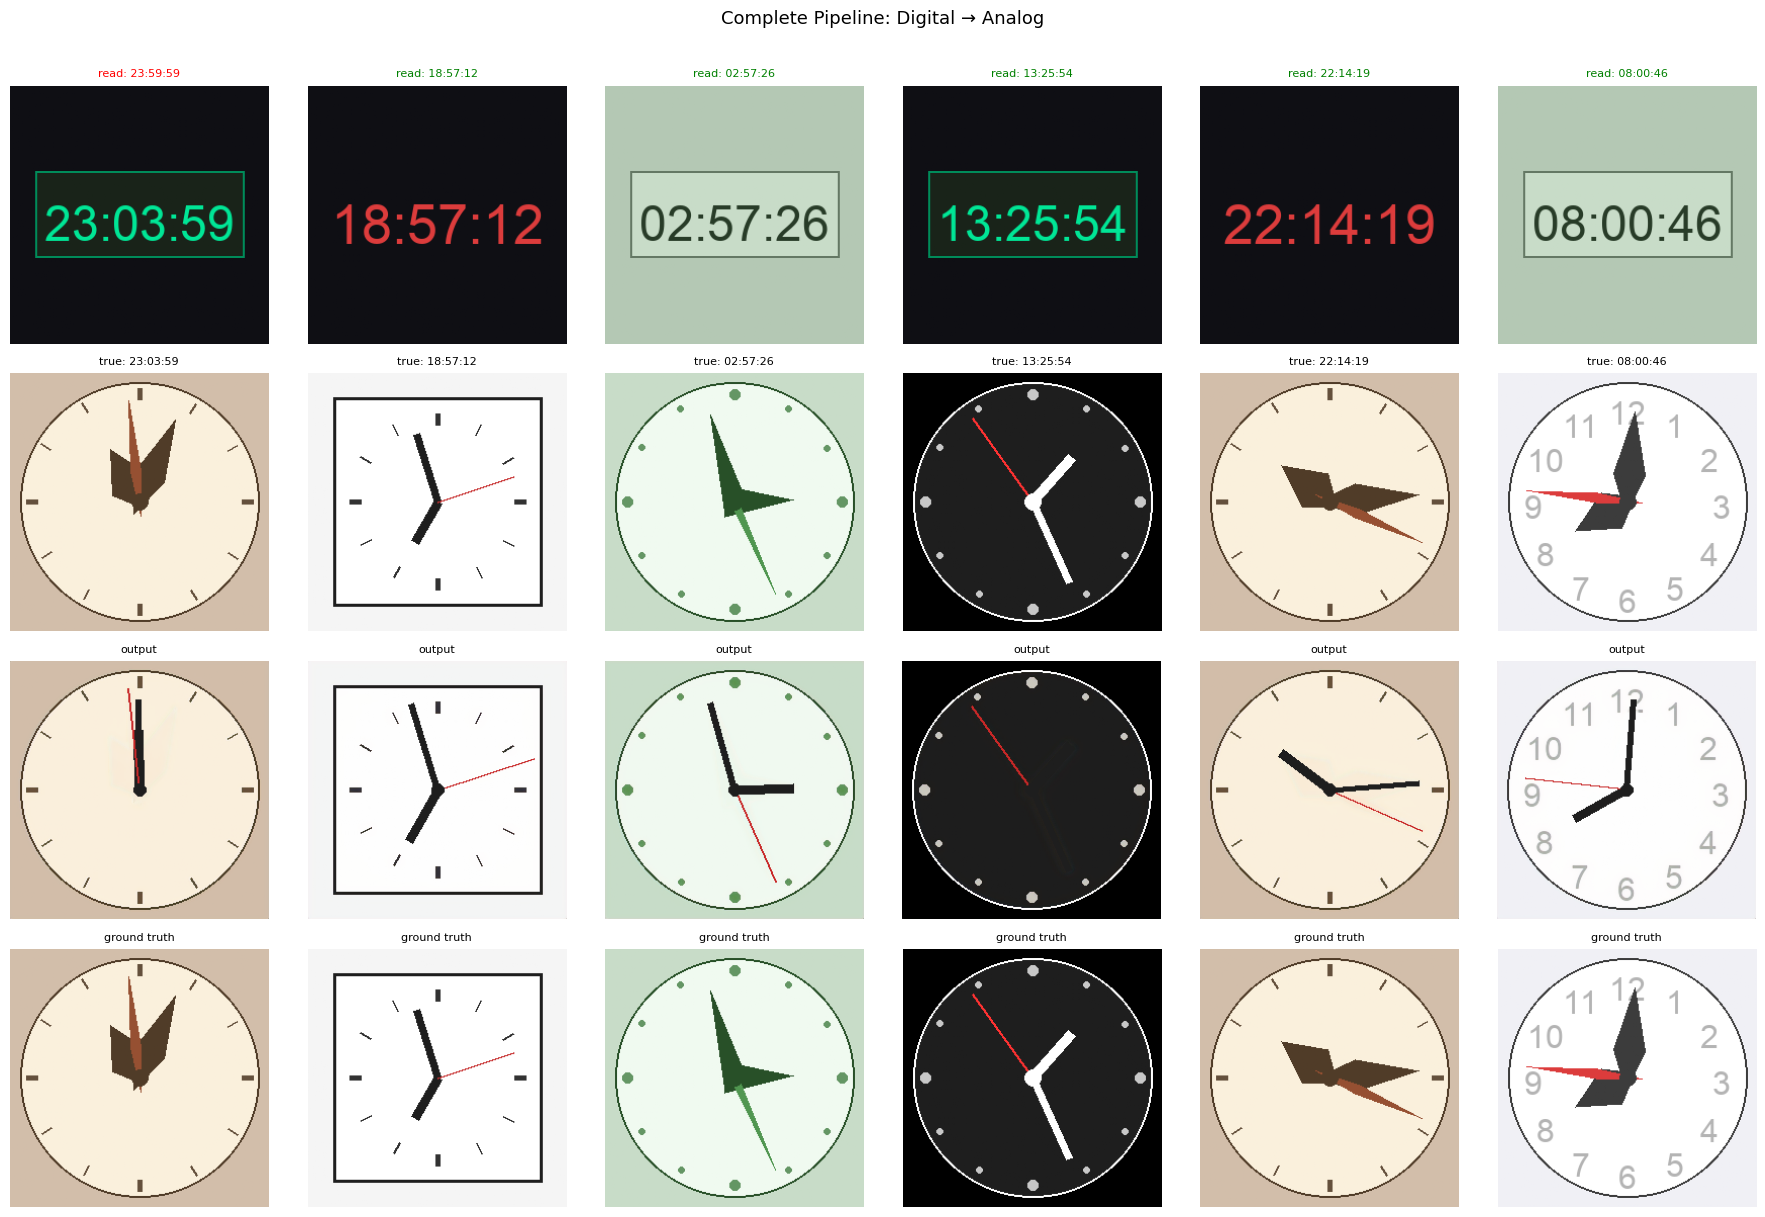

Saved final_pipeline.png


In [6]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
reader_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

ds     = ClockDataset("./clock_dataset", subset='test', transform=transform)
loader = DataLoader(ds, batch_size=6, shuffle=True, num_workers=0)
batch  = next(iter(loader))

# Re-transform digital images for reader (needs normalization)
dig_for_reader = torch.stack([
    reader_transform(
        transforms.ToPILImage()(batch['digital_img'][i])
    ) for i in range(len(batch['digital_img']))
]).to(device)

analog_imgs = batch['analog_img'].to(device)
true_times  = batch['original_time']

with torch.no_grad():
    # Stage 1: read time from digital clock
    h_pred, m_pred, s_pred = reader.predict_time(dig_for_reader)

    # Stage 2: erase hands from analog clock
    clean_faces = eraser(analog_imgs)

    # Stage 3: draw correct hands using geometry
    outputs = draw_hands_on_tensor(clean_faces.cpu(), h_pred.cpu(), m_pred.cpu(), s_pred.cpu())

# ── Visualize ──
n = len(batch['digital_img'])
fig, axes = plt.subplots(4, n, figsize=(3*n, 12))
row_labels = ['Digital input', 'Analog input', 'Our output', 'Ground truth']

for i in range(n):
    h_t = int(true_times[i][0])
    m_t = int(true_times[i][1])
    s_t = int(true_times[i][2])
    h_p = int(h_pred[i].item())
    m_p = int(m_pred[i].item())
    s_p = int(s_pred[i].item())
    correct = (h_t==h_p and m_t==m_p and s_t==s_p)

    axes[0,i].imshow(batch['digital_img'][i].permute(1,2,0))
    axes[0,i].set_title(
        f"read: {h_p:02d}:{m_p:02d}:{s_p:02d}",
        color='green' if correct else 'red', fontsize=8
    )

    axes[1,i].imshow(analog_imgs[i].cpu().permute(1,2,0))
    axes[1,i].set_title(f"true: {h_t:02d}:{m_t:02d}:{s_t:02d}", fontsize=8)

    axes[2,i].imshow(outputs[i].permute(1,2,0).clamp(0,1))
    axes[2,i].set_title("output", fontsize=8)

    axes[3,i].imshow(batch['analog_img'][i].permute(1,2,0))
    axes[3,i].set_title("ground truth", fontsize=8)

    for r in range(4):
        if i == 0:
            axes[r,0].set_ylabel(row_labels[r], fontsize=9, rotation=90)
        axes[r,i].axis('off')

plt.suptitle("Complete Pipeline: Digital → Analog", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()